In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [3]:
image_cut = image[55:155, 0:1890]
image_error_cut = image_error[55:155, 0:1890]

Text(0.5, 0, 'wavelength')

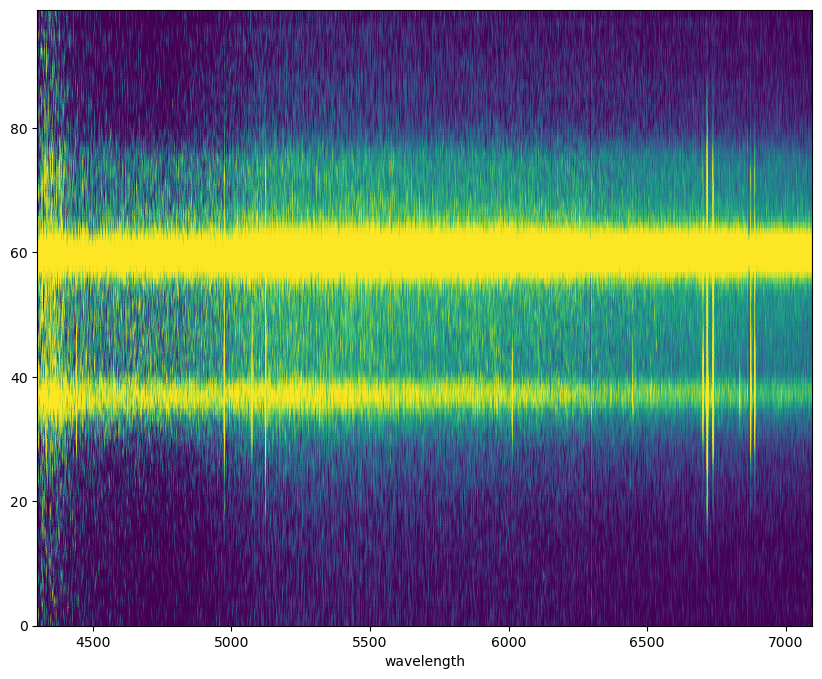

In [4]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [5]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/PSF/Real_seeing_Mrk544.txt")
sigmas = seeing / 2.35
n_component = 4
print(sigmas)

[1.33125689 1.51991163 1.32910514 1.31568119 1.50420362]


In [6]:
l_HA

6719.1994

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


Text(0.5, 0, 'wavelenght')

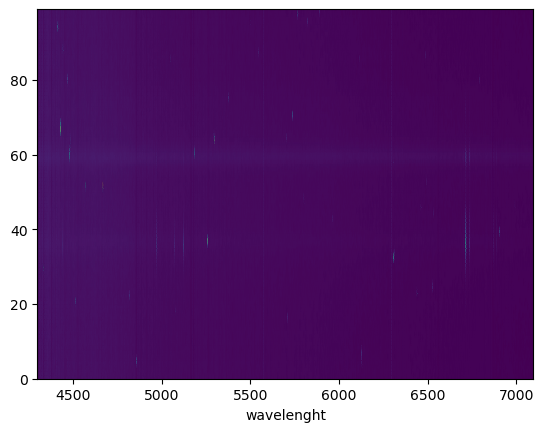

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[55:155, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

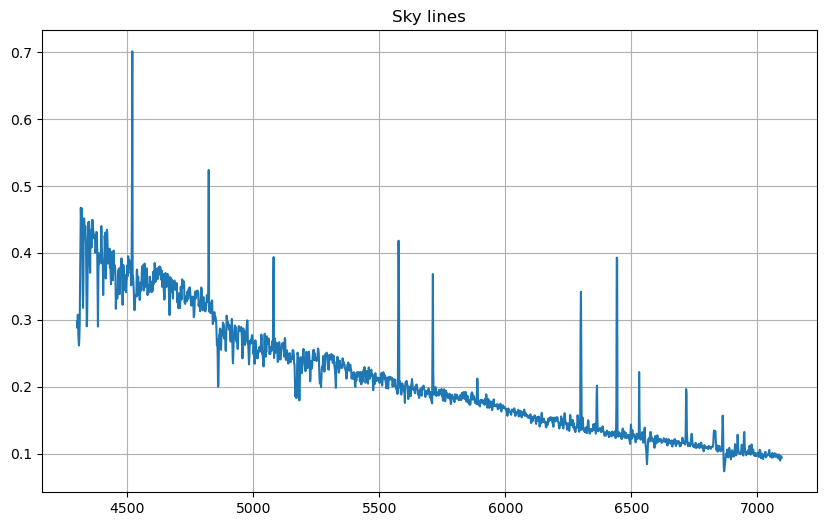

In [8]:
mask_sky = (y > 15)*(y < 25)
image_sky = image_cut2[mask_sky, :]
radial_profile_sky = np.mean(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv, radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

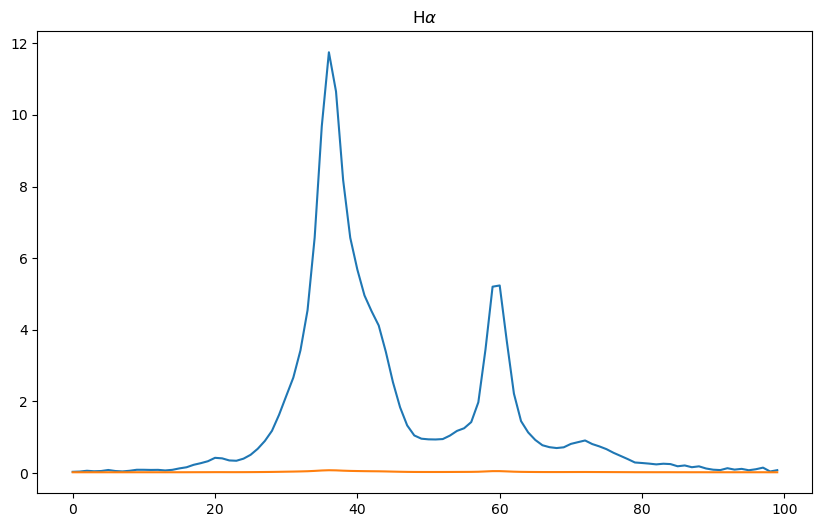

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Propagazione_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [10]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) #+
        #sersic_1d(x_hr, *params[16:20])+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (70, 80)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [12]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 11658.086179988228
differential_evolution step 2: f(x)= 11658.086179988228
differential_evolution step 3: f(x)= 4866.9911912394045
differential_evolution step 4: f(x)= 4550.259609974558
differential_evolution step 5: f(x)= 4550.259609974558
differential_evolution step 6: f(x)= 2722.161146732564
differential_evolution step 7: f(x)= 478.1184743007494
differential_evolution step 8: f(x)= 478.1184743007494
differential_evolution step 9: f(x)= 478.1184743007494
differential_evolution step 10: f(x)= 478.1184743007494
differential_evolution step 11: f(x)= 478.1184743007494
differential_evolution step 12: f(x)= 478.1184743007494
differential_evolution step 13: f(x)= 478.1184743007494
differential_evolution step 14: f(x)= 337.786287059297
differential_evolution step 15: f(x)= 337.786287059297
differential_evolution step 16: f(x)= 337.786287059297
differential_evolution step 17: f(x)= 337.786287059297
differential_evolution step 18: f(x)= 337.786287059297
dif

Sérsic 1: I_e=0.6896, r_e=10.4506, n=2.0623, x_0=36.1477
Sérsic 2: I_e=0.4252, r_e=6.5880, n=1.3614, x_0=41.9641
Sérsic 3: I_e=0.1858, r_e=8.2399, n=2.8627, x_0=59.5386
Sérsic 4: I_e=0.0689, r_e=25.7034, n=1.5225, x_0=72.0577


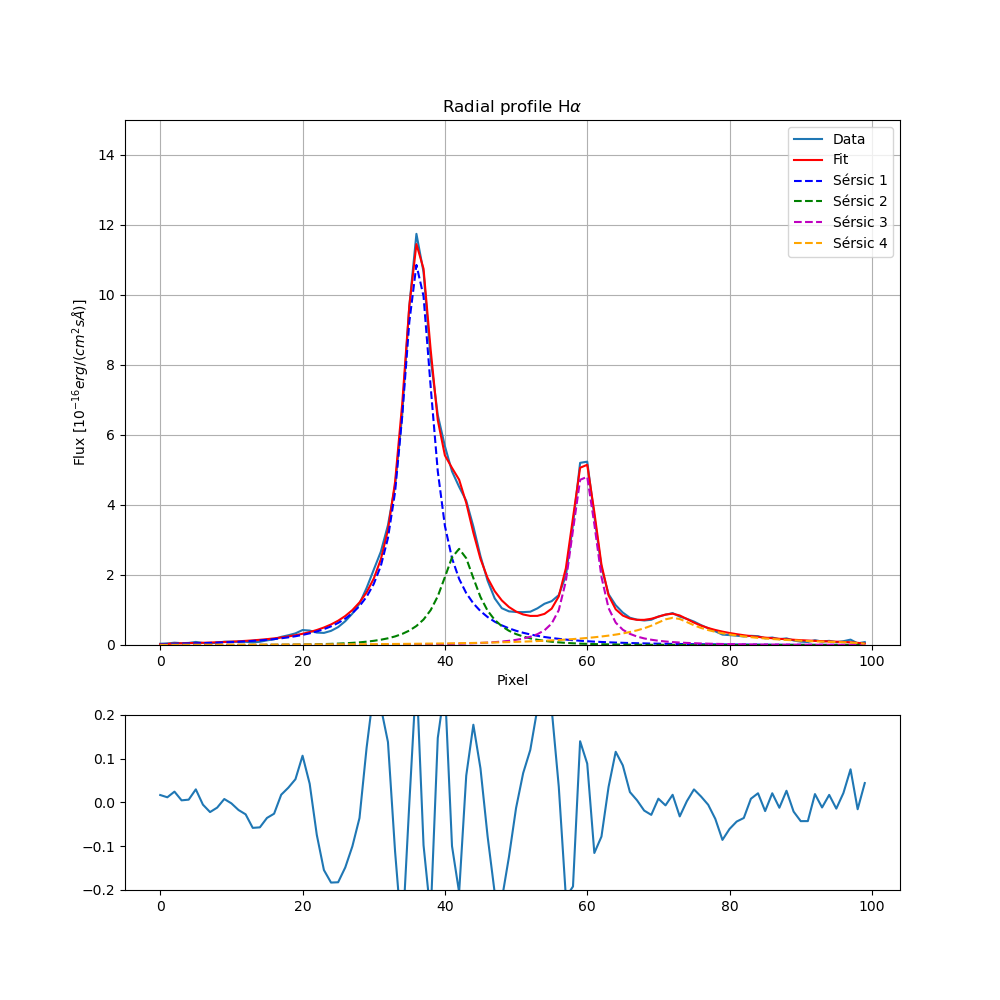

In [17]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [18]:
print(result.x)

[6.89570486e-01 1.04506303e+01 2.06226369e+00 3.61477324e+01
 4.25205418e-01 6.58804909e+00 1.36135991e+00 4.19641001e+01
 1.85769196e-01 8.23990582e+00 2.86272967e+00 5.95386347e+01
 6.88989559e-02 2.57033937e+01 1.52254130e+00 7.20576847e+01]


In [22]:
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.2017, r_e=7.4647, n=1.6351, x_0=36.2560
Sérsic 2: I_e=0.1454, r_e=10.6858, n=2.1946, x_0=42.4210
Sérsic 3: I_e=0.0762, r_e=18.8709, n=3.3478, x_0=59.5386
Sérsic 4: I_e=0.0219, r_e=53.3870, n=2.2190, x_0=72.2994
[2.27602536e-01 1.04552159e+00 1.51727765e-01 7.59198361e-02
 3.60565649e-01 2.27668094e+01 1.76197605e+00 1.95994744e-01
 6.51356802e-01 1.14104997e+02 8.57027546e+00 1.42287959e-03
 2.23858985e-02 6.87590714e+01 6.73520617e-01 3.54279091e-01]
1.1629157337833989


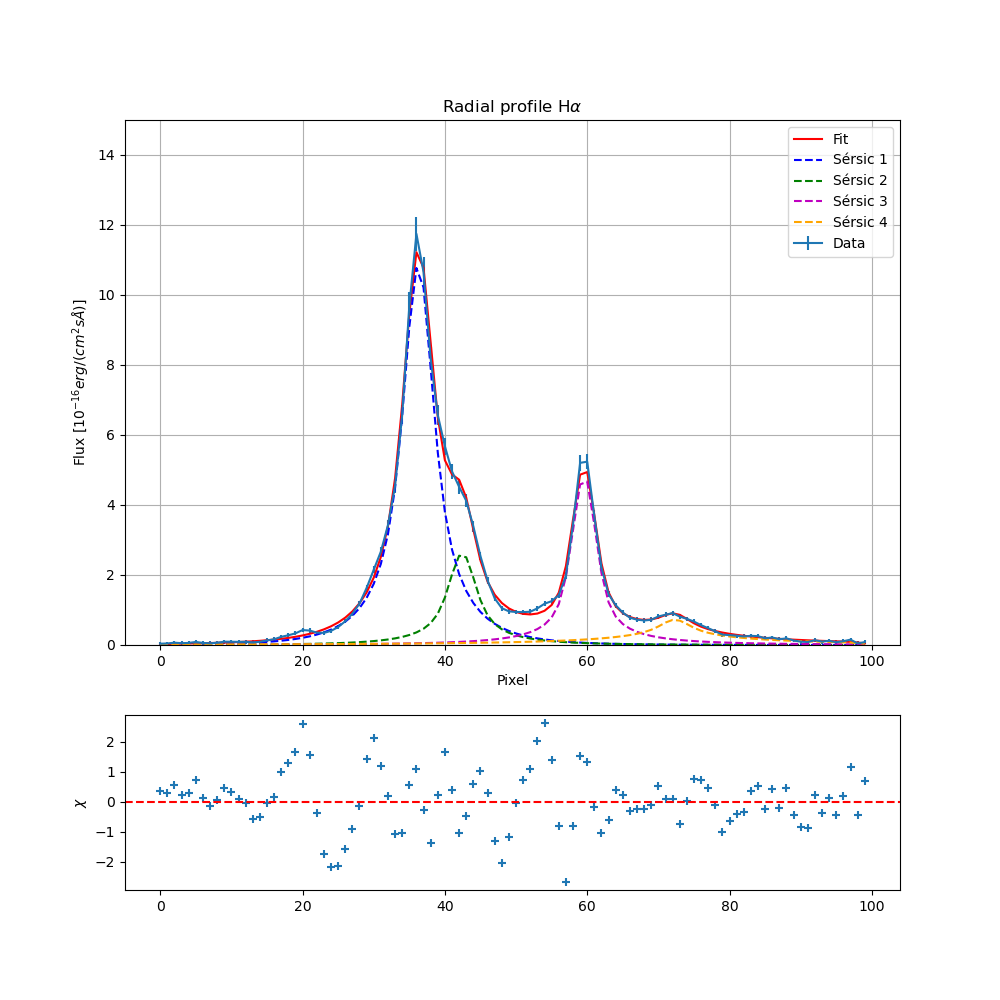

In [23]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [24]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

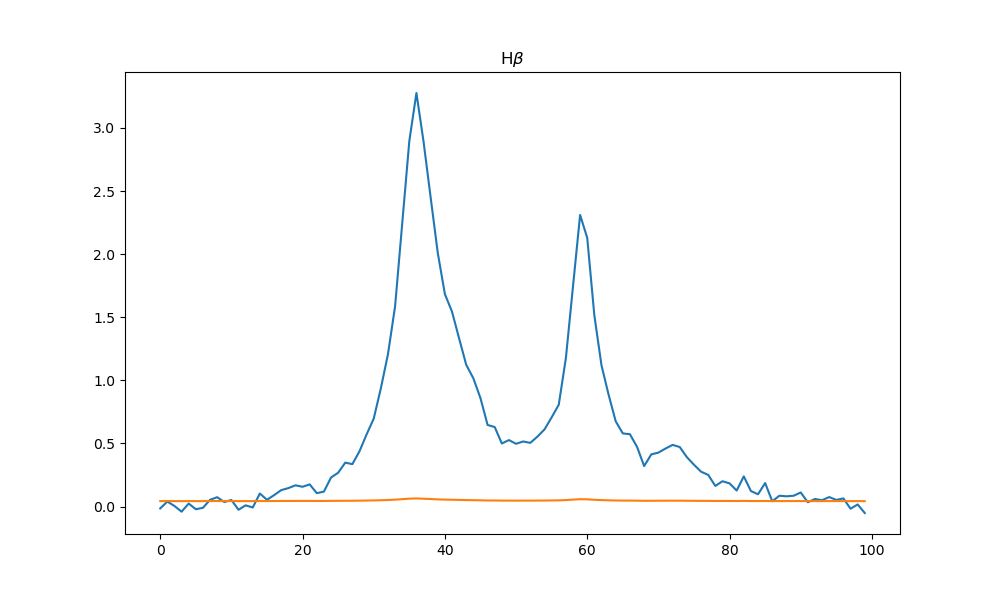

In [25]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[0])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [26]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 13.853765365655429
differential_evolution step 2: f(x)= 8.035627550563257
differential_evolution step 3: f(x)= 8.035627550563257
differential_evolution step 4: f(x)= 7.45319354992128
differential_evolution step 5: f(x)= 4.038025538572887
differential_evolution step 6: f(x)= 2.6974705329096285
differential_evolution step 7: f(x)= 2.2596608898775288
differential_evolution step 8: f(x)= 2.2596608898775288
differential_evolution step 9: f(x)= 2.2596608898775288
differential_evolution step 10: f(x)= 2.2596608898775288
differential_evolution step 11: f(x)= 2.2596608898775288
differential_evolution step 12: f(x)= 2.2596608898775288
differential_evolution step 13: f(x)= 2.2596608898775288
differential_evolution step 14: f(x)= 2.2596608898775288
differential_evolution step 15: f(x)= 1.5437101285557637
differential_evolution step 16: f(x)= 1.5437101285557637
differential_evolution step 17: f(x)= 1.5437101285557637
differential_evolution step 18: f(x)= 1.54371

Sérsic 1: I_e=0.1000, r_e=16.1632, n=2.5521, x_0=35.8788
Sérsic 2: I_e=0.0998, r_e=12.6767, n=1.4431, x_0=40.9399
Sérsic 3: I_e=0.0274, r_e=26.4415, n=3.4055, x_0=59.3653
Sérsic 4: I_e=0.0469, r_e=17.1808, n=1.2535, x_0=71.8907


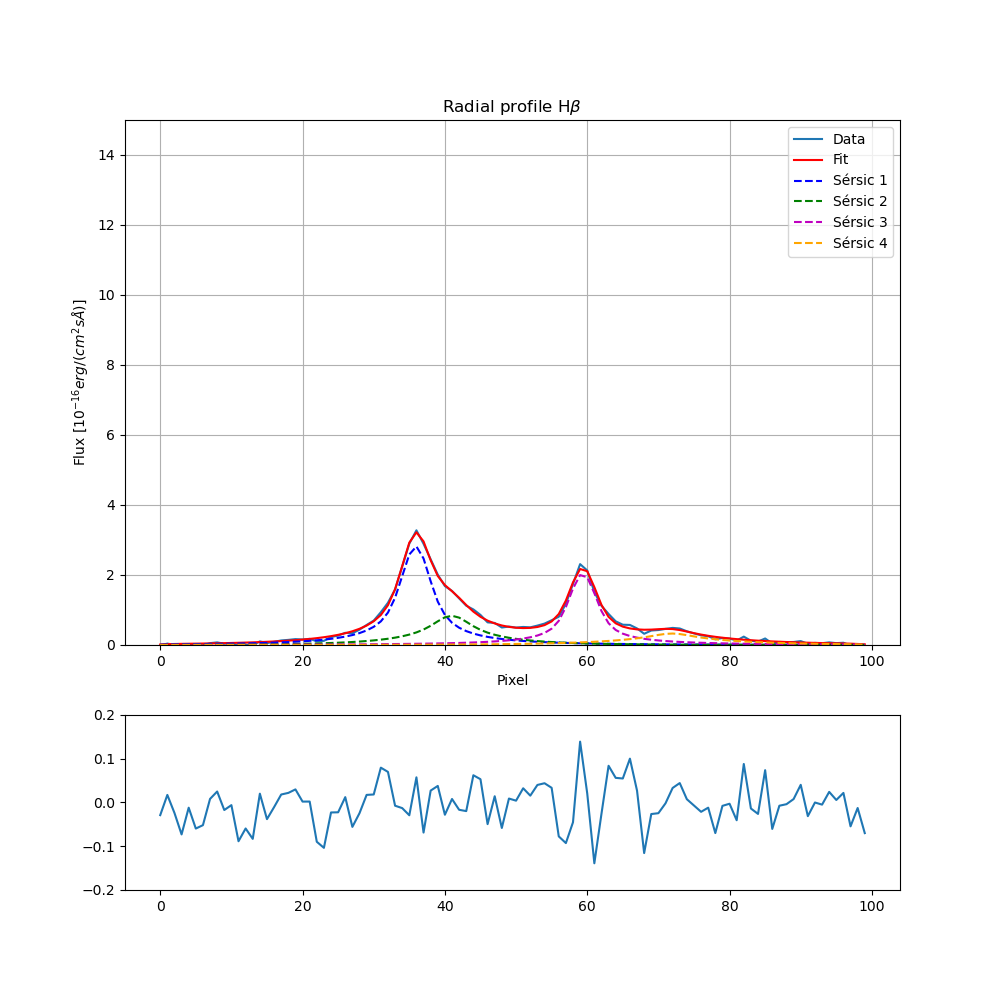

In [27]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [28]:
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=0.1573, r_e=12.2797, n=2.1690, x_0=35.8719
Sérsic 2: I_e=0.1617, r_e=8.5457, n=1.0800, x_0=40.9497
Sérsic 3: I_e=0.0256, r_e=32.0384, n=3.3660, x_0=59.3653
Sérsic 4: I_e=0.0357, r_e=18.9243, n=1.4355, x_0=72.0990
[9.87060824e-02 6.32225161e+00 4.13016078e-01 1.10131890e-01
 1.29877727e-01 5.51033221e+00 5.17549852e-01 7.73748903e-01
 1.14631107e-01 1.05916049e+02 4.18437815e+00 1.05405573e-03
 3.59045040e-02 2.27772969e+01 6.96547595e-01 5.29922875e-01]
0.25793303018187735


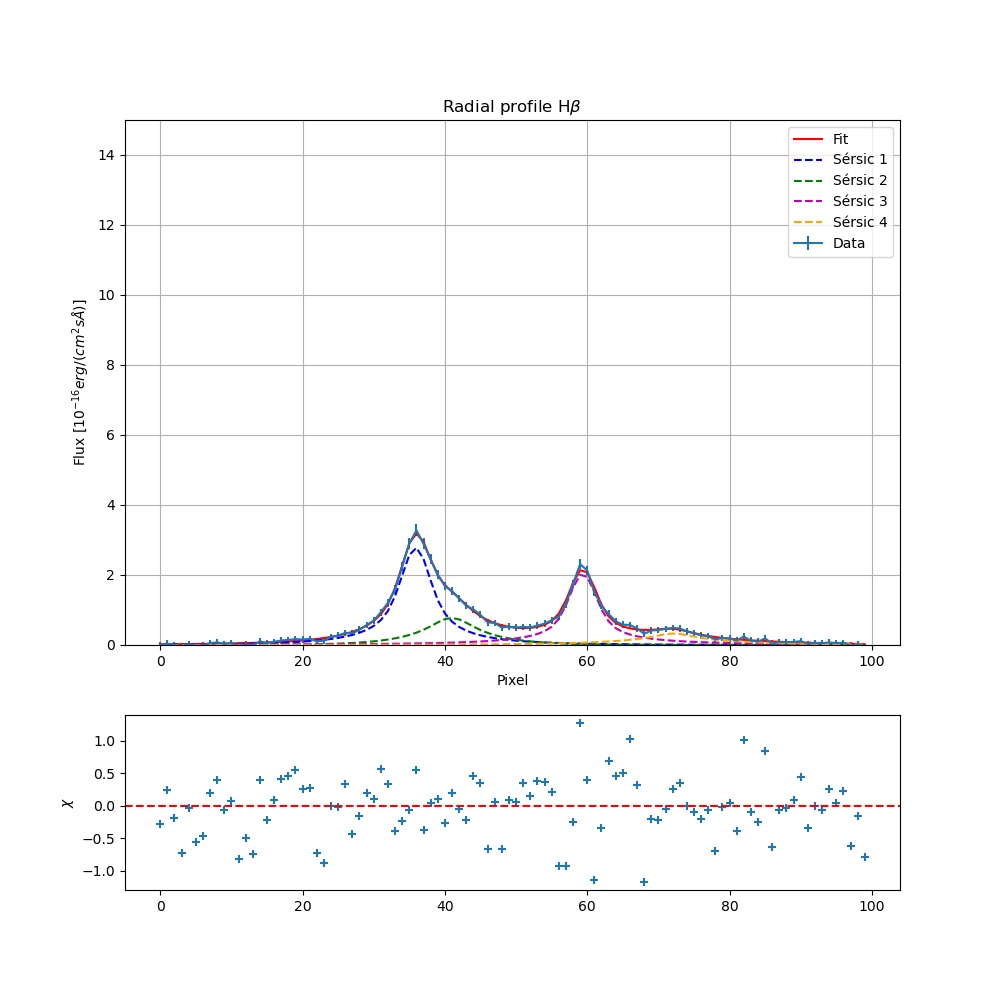

In [29]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

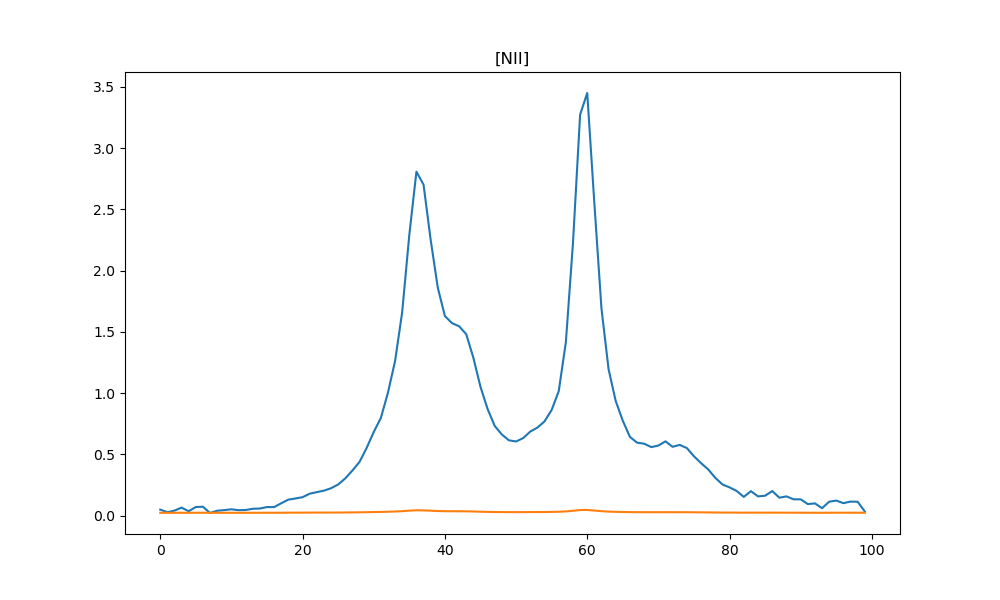

In [30]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [31]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 12.198445433615714
differential_evolution step 2: f(x)= 12.198445433615714
differential_evolution step 3: f(x)= 8.739971613313175
differential_evolution step 4: f(x)= 6.141826299786269
differential_evolution step 5: f(x)= 5.957667400399943
differential_evolution step 6: f(x)= 4.8772688998568245
differential_evolution step 7: f(x)= 4.8772688998568245
differential_evolution step 8: f(x)= 4.8772688998568245
differential_evolution step 9: f(x)= 4.8772688998568245
differential_evolution step 10: f(x)= 4.8772688998568245
differential_evolution step 11: f(x)= 4.8772688998568245
differential_evolution step 12: f(x)= 4.8772688998568245
differential_evolution step 13: f(x)= 4.8772688998568245
differential_evolution step 14: f(x)= 4.8772688998568245
differential_evolution step 15: f(x)= 4.8772688998568245
differential_evolution step 16: f(x)= 4.8772688998568245
differential_evolution step 17: f(x)= 4.8772688998568245
differential_evolution step 18: f(x)= 4.877

Sérsic 1: I_e=0.1000, r_e=17.3431, n=2.3028, x_0=36.2827
Sérsic 2: I_e=0.0949, r_e=11.7319, n=1.5576, x_0=42.3770
Sérsic 3: I_e=0.0214, r_e=41.0537, n=3.8892, x_0=59.6624
Sérsic 4: I_e=0.0472, r_e=23.1389, n=1.3593, x_0=72.1653


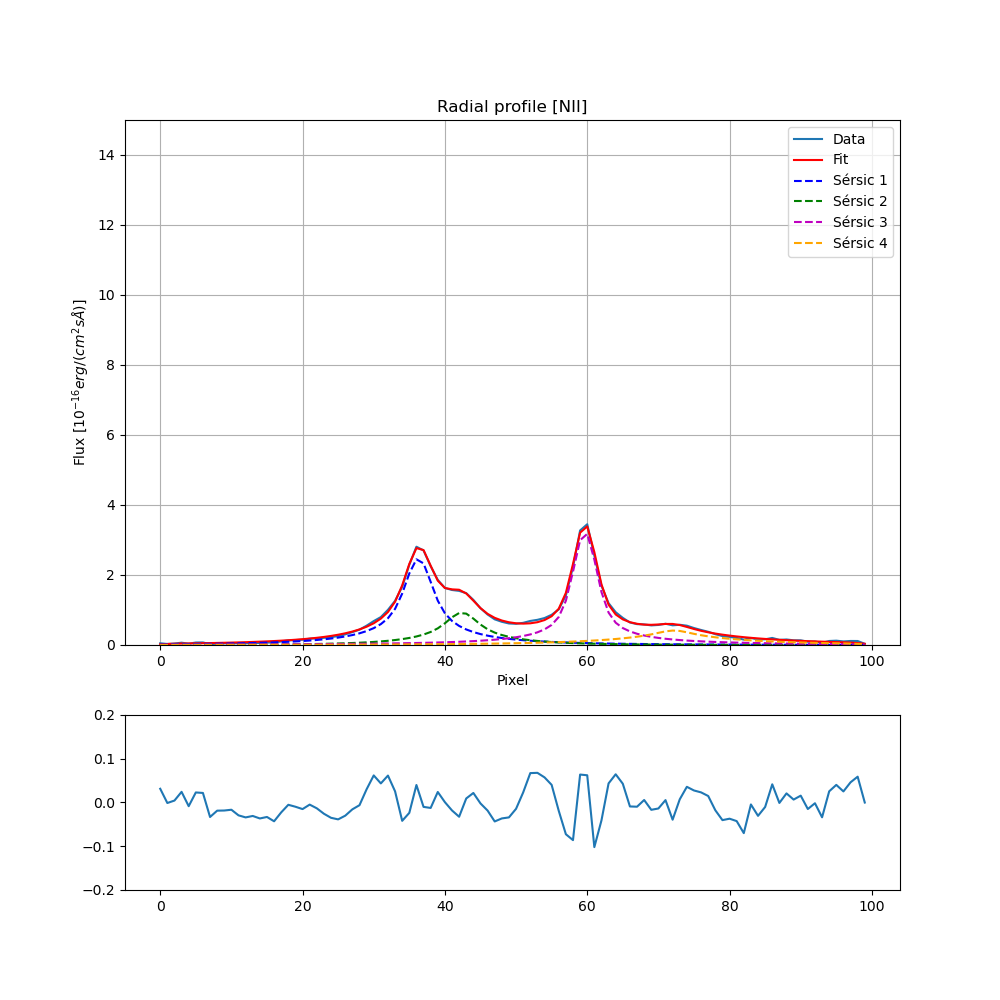

In [32]:
# Plots:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [33]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII) #, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.1631, r_e=12.5924, n=1.9426, x_0=36.3104
Sérsic 2: I_e=0.0898, r_e=10.5234, n=1.5818, x_0=42.5376
Sérsic 3: I_e=0.0200, r_e=49.5985, n=3.8379, x_0=59.6624
Sérsic 4: I_e=0.0282, r_e=30.5400, n=1.6674, x_0=72.5476
[5.63287176e-02 3.74635194e+00 2.45342693e-01 6.11342478e-02
 7.32507762e-02 8.05766468e+00 5.60876156e-01 1.62857564e-01
 5.20883775e-02 9.78221391e+01 2.31833741e+00 2.29910363e-04
 1.73642107e-02 2.41522318e+01 4.16402021e-01 2.76508354e-01]
0.2539129013750234


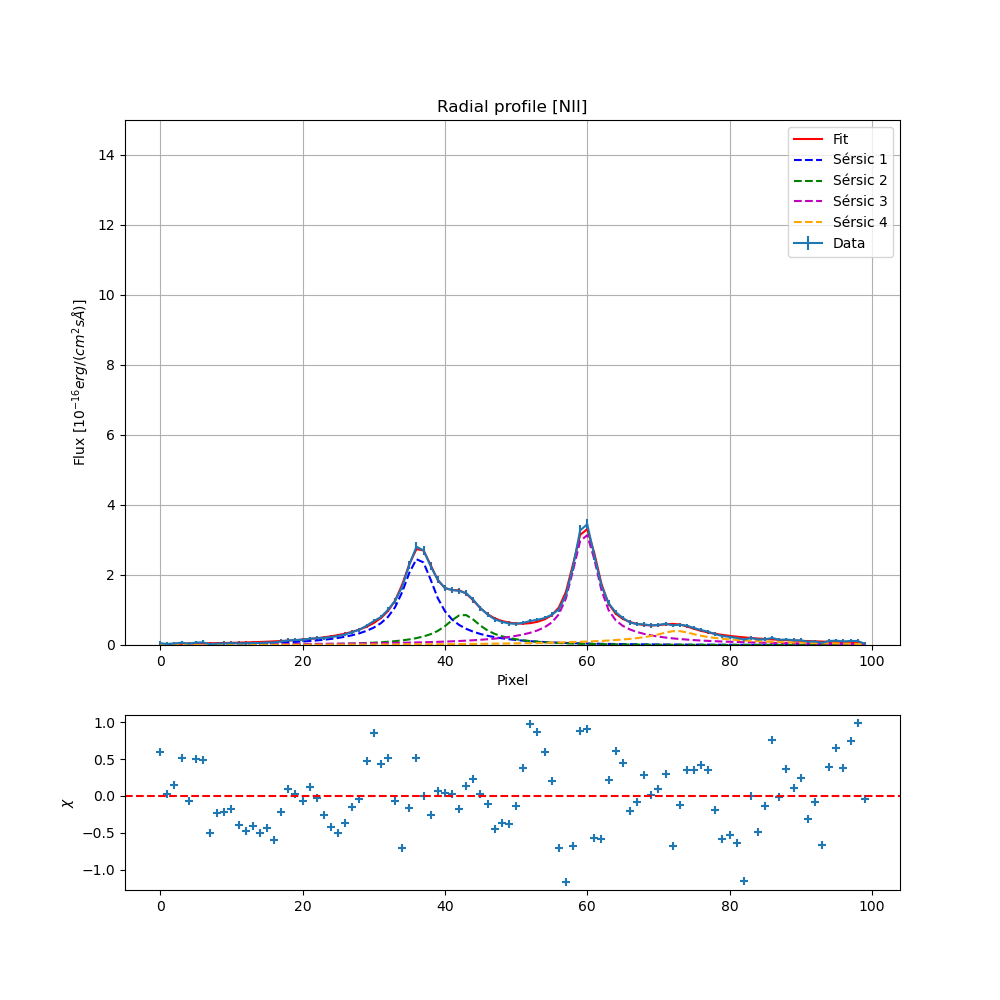

In [34]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

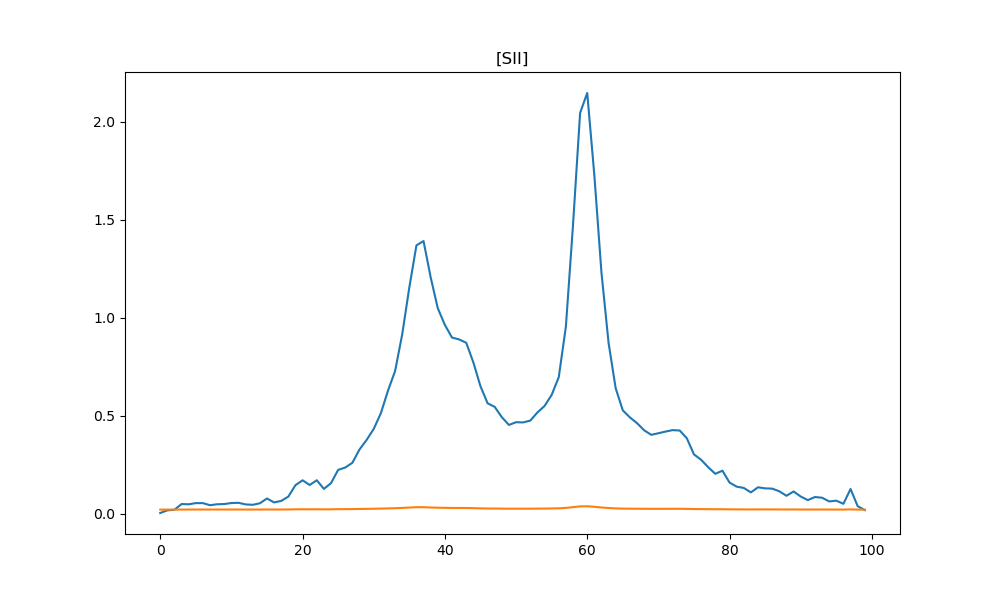

In [35]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[3])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [36]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1.8433409387946422
differential_evolution step 2: f(x)= 1.8433409387946422
differential_evolution step 3: f(x)= 1.8433409387946422
differential_evolution step 4: f(x)= 1.8433409387946422
differential_evolution step 5: f(x)= 1.8433409387946422
differential_evolution step 6: f(x)= 1.8433409387946422
differential_evolution step 7: f(x)= 1.8146996334715724
differential_evolution step 8: f(x)= 1.8146996334715724
differential_evolution step 9: f(x)= 1.8146996334715724
differential_evolution step 10: f(x)= 1.5874597543878777
differential_evolution step 11: f(x)= 1.5874597543878777
differential_evolution step 12: f(x)= 1.5874597543878777
differential_evolution step 13: f(x)= 1.5605542545580076
differential_evolution step 14: f(x)= 1.5605542545580076
differential_evolution step 15: f(x)= 0.9652911963117231
differential_evolution step 16: f(x)= 0.9652911963117231
differential_evolution step 17: f(x)= 0.342565875551966
differential_evolution step 18: f(x)= 0.3

Sérsic 1: I_e=0.0997, r_e=12.7543, n=1.6615, x_0=36.3879
Sérsic 2: I_e=0.0383, r_e=22.5001, n=1.6116, x_0=42.5762
Sérsic 3: I_e=0.0260, r_e=29.3171, n=3.2834, x_0=59.7367
Sérsic 4: I_e=0.0148, r_e=44.6784, n=1.8428, x_0=72.1214


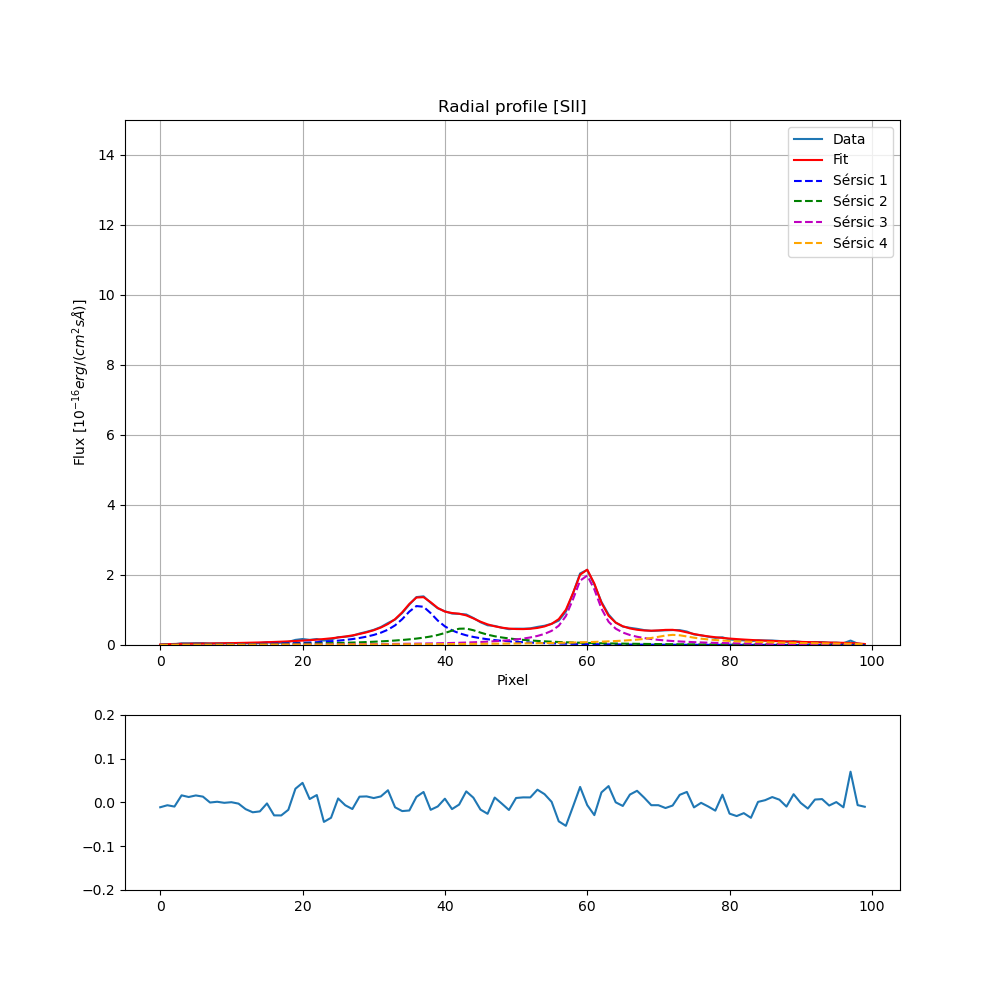

In [37]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [38]:
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.1012, r_e=12.9542, n=1.6518, x_0=36.3999
Sérsic 2: I_e=0.0374, r_e=21.4024, n=1.6227, x_0=42.6288
Sérsic 3: I_e=0.0260, r_e=30.1489, n=3.2687, x_0=59.7367
Sérsic 4: I_e=0.0144, r_e=44.1089, n=1.8673, x_0=72.1496
[4.72509258e-02 7.08636217e+00 3.18887802e-01 8.08391944e-02
 3.32562105e-02 3.59349432e+01 6.12963743e-01 2.52506312e-01
 1.62254216e-01 1.47457932e+02 5.32856104e+00 1.25449601e-03
 9.37366708e-03 5.27557911e+01 4.43976474e-01 2.99840232e-01]
0.1336418074253261


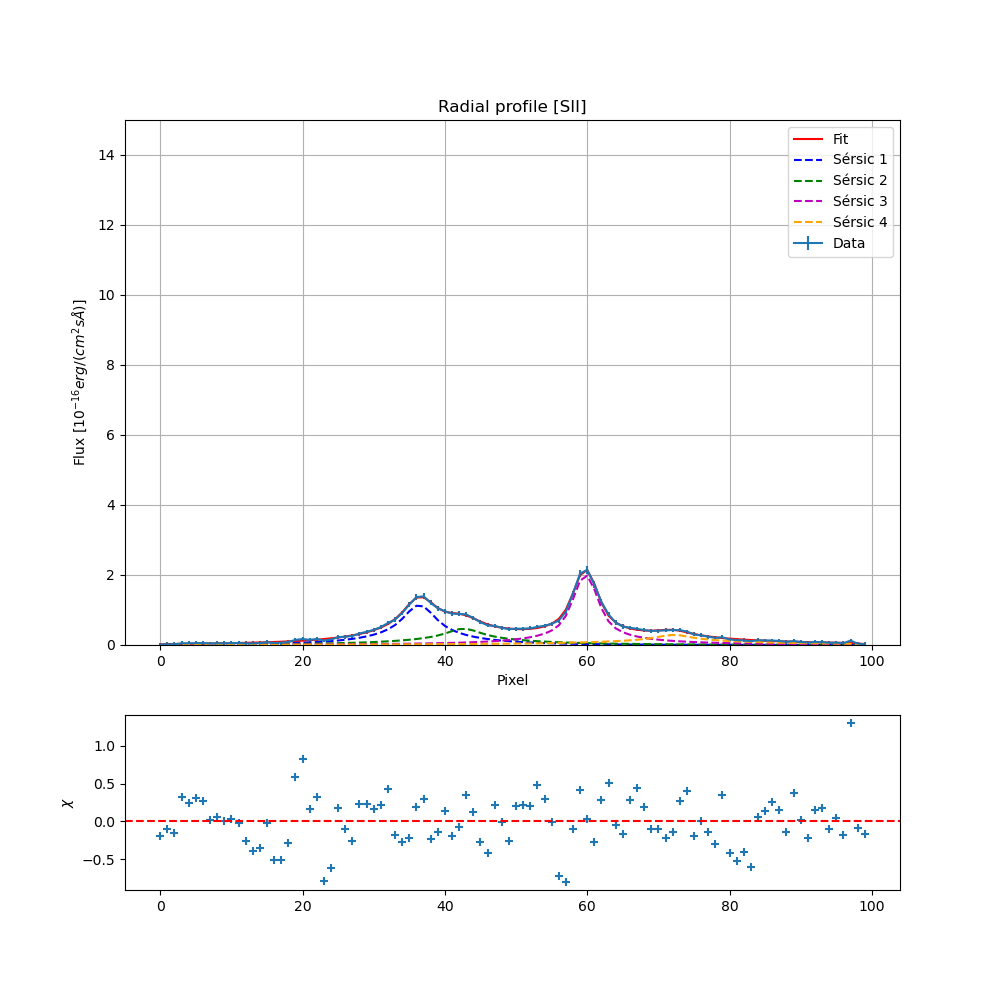

In [39]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

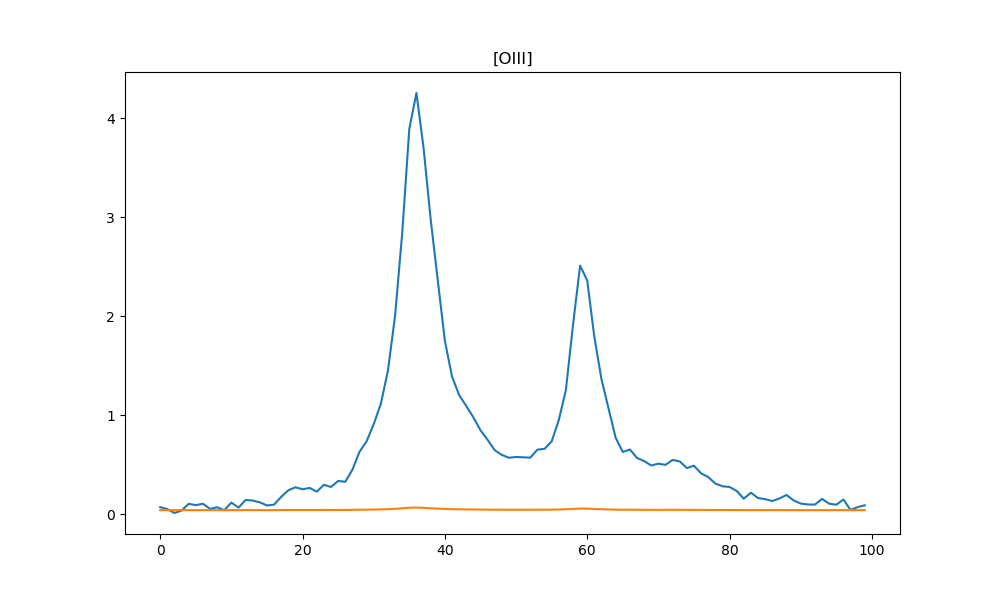

In [40]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[1])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [41]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 18.193233461559696
differential_evolution step 2: f(x)= 7.181665803280225
differential_evolution step 3: f(x)= 3.4758935414676246
differential_evolution step 4: f(x)= 3.4758935414676246
differential_evolution step 5: f(x)= 3.4758935414676246
differential_evolution step 6: f(x)= 3.4758935414676246
differential_evolution step 7: f(x)= 3.4758935414676246
differential_evolution step 8: f(x)= 3.4758935414676246
differential_evolution step 9: f(x)= 1.8264138240238728
differential_evolution step 10: f(x)= 1.8264138240238728
differential_evolution step 11: f(x)= 1.8264138240238728
differential_evolution step 12: f(x)= 1.8264138240238728
differential_evolution step 13: f(x)= 1.8264138240238728
differential_evolution step 14: f(x)= 1.8264138240238728
differential_evolution step 15: f(x)= 1.2664498349644038
differential_evolution step 16: f(x)= 1.2664498349644038
differential_evolution step 17: f(x)= 1.2664498349644038
differential_evolution step 18: f(x)= 1.2

Sérsic 1: I_e=0.0966, r_e=22.0959, n=2.7930, x_0=35.9312
Sérsic 2: I_e=0.0996, r_e=8.9363, n=0.9946, x_0=40.9387
Sérsic 3: I_e=0.0233, r_e=33.5230, n=3.5410, x_0=59.4891
Sérsic 4: I_e=0.0478, r_e=26.6420, n=1.2882, x_0=72.3889


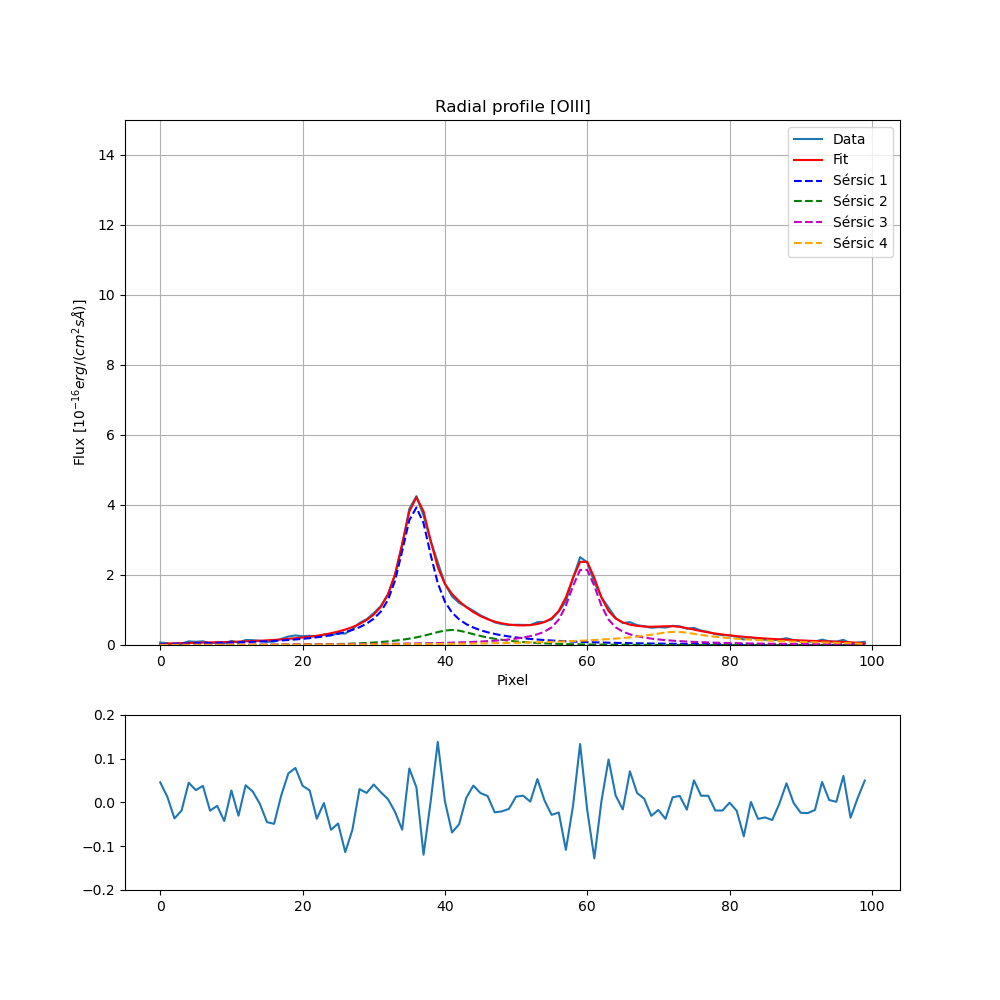

In [42]:
# Plots:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [43]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0977, r_e=22.2041, n=2.7482, x_0=35.9548
Sérsic 2: I_e=0.1939, r_e=6.1962, n=0.5366, x_0=40.1343
Sérsic 3: I_e=0.0227, r_e=38.1415, n=3.4939, x_0=59.4891
Sérsic 4: I_e=0.0393, r_e=27.2257, n=1.3932, x_0=72.6682
[1.12454231e-01 1.68806609e+01 8.44094586e-01 5.39320482e-02
 1.28126002e-01 1.77918251e+00 2.29388555e-01 2.87535056e+00
 1.32053141e-01 1.67618772e+02 5.18570410e+00 8.66165108e-04
 2.61228701e-02 2.54415385e+01 4.62480496e-01 5.24338397e-01]
0.24977797336796254


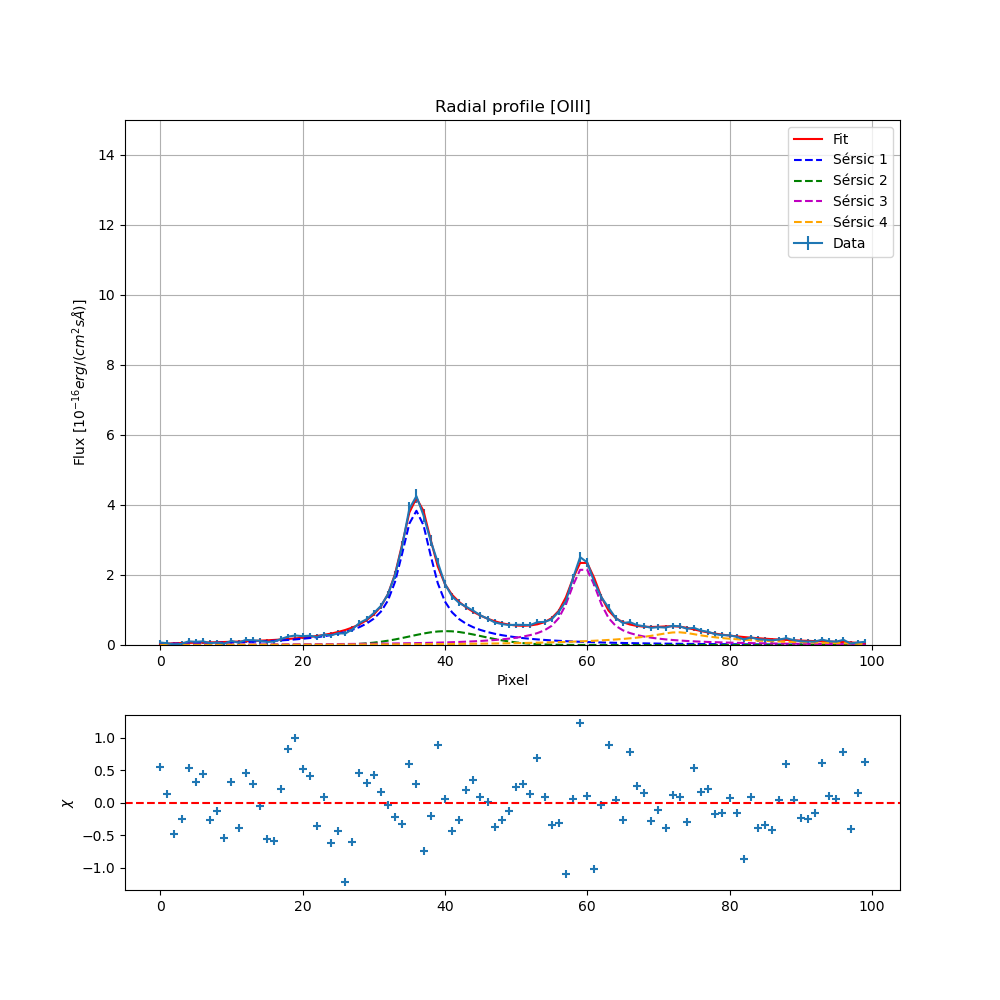

In [44]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [45]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

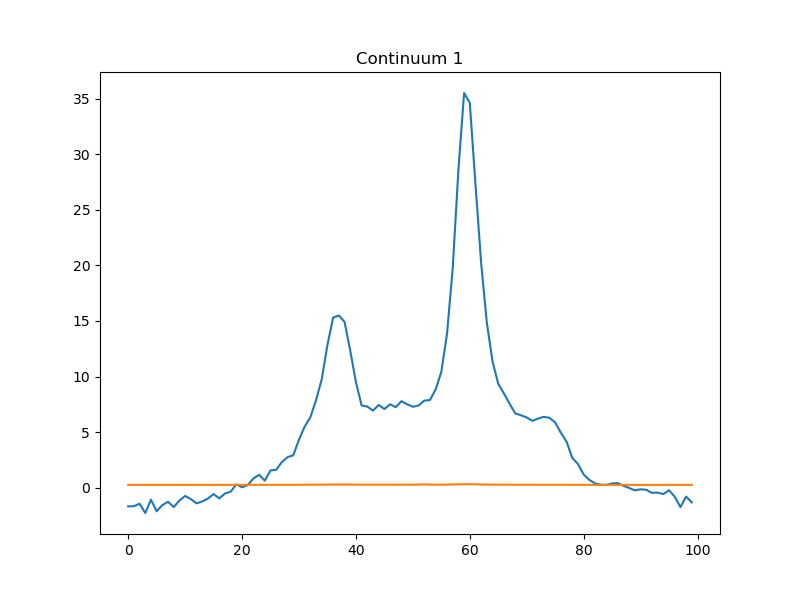

In [46]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[0])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [47]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 8856.373120789418
differential_evolution step 2: f(x)= 4957.7589767672725
differential_evolution step 3: f(x)= 4957.7589767672725
differential_evolution step 4: f(x)= 4957.7589767672725
differential_evolution step 5: f(x)= 4957.7589767672725
differential_evolution step 6: f(x)= 2674.4779529342104
differential_evolution step 7: f(x)= 648.8853907318187
differential_evolution step 8: f(x)= 648.8853907318187
differential_evolution step 9: f(x)= 648.8853907318187
differential_evolution step 10: f(x)= 648.8853907318187
differential_evolution step 11: f(x)= 648.8853907318187
differential_evolution step 12: f(x)= 648.8853907318187
differential_evolution step 13: f(x)= 648.8853907318187
differential_evolution step 14: f(x)= 648.8853907318187
differential_evolution step 15: f(x)= 648.8853907318187
differential_evolution step 16: f(x)= 648.8853907318187
differential_evolution step 17: f(x)= 648.8853907318187
differential_evolution step 18: f(x)= 648.8853907318

In [48]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    

Sérsic 1: I_e=3.6527, r_e=6.7462, n=1.0362, x_0=36.8325
Sérsic 2: I_e=5.0199, r_e=4.5589, n=0.1372, x_0=49.3000
Sérsic 3: I_e=6.0813, r_e=4.0336, n=1.5318, x_0=59.3594
Sérsic 4: I_e=5.2341, r_e=6.4088, n=0.1332, x_0=70.0000


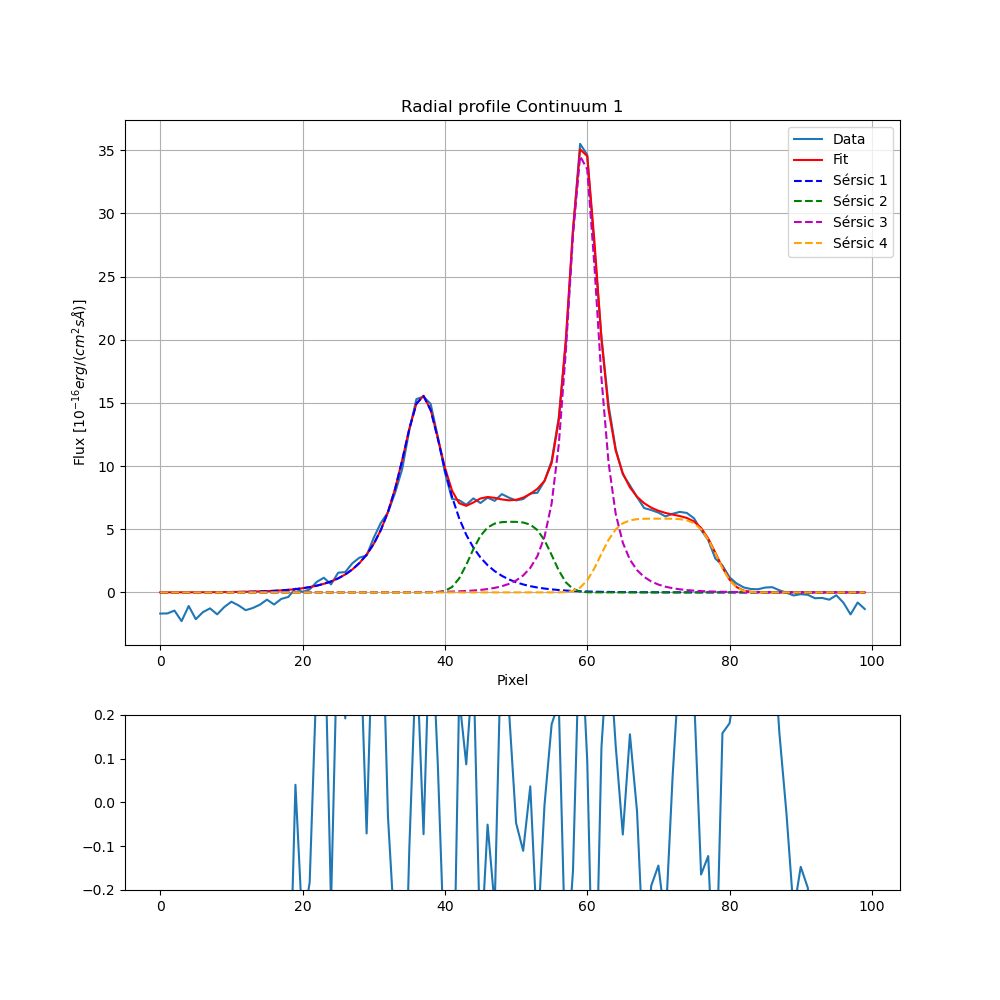

In [49]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [50]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=4.0943, r_e=6.4583, n=0.9319, x_0=36.8070
Sérsic 2: I_e=5.2654, r_e=4.3382, n=0.1549, x_0=49.3549
Sérsic 3: I_e=8.4067, r_e=3.4087, n=1.2423, x_0=59.3726
Sérsic 4: I_e=5.2590, r_e=6.0266, n=0.1878, x_0=70.0000
[0.99862986 0.89985176 0.18845576 0.27076143 0.83946981 1.32967657
 0.25669458 1.55314896 7.24009595 1.36101876 0.77723472 0.49098807
 0.96610587 3.51051269 0.12445124 4.84523578]
7.4099091781125574


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\1627898622.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


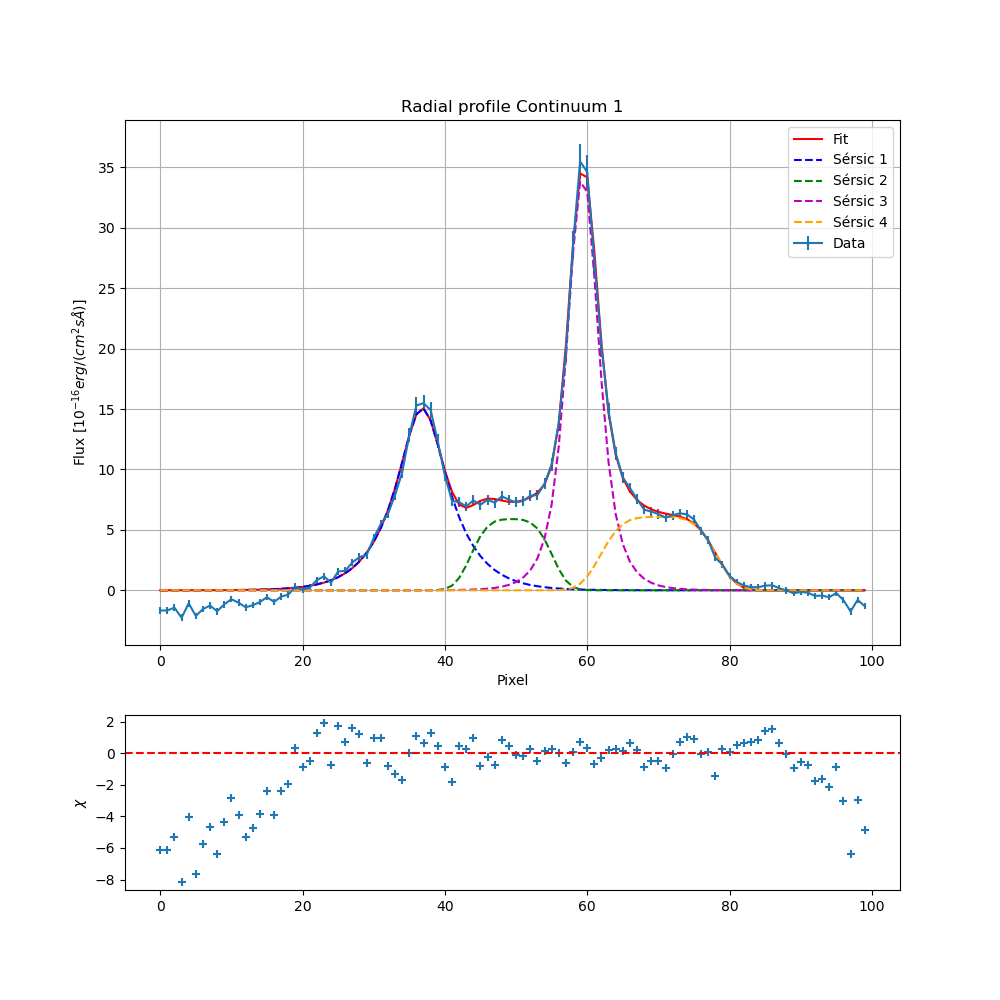

In [51]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

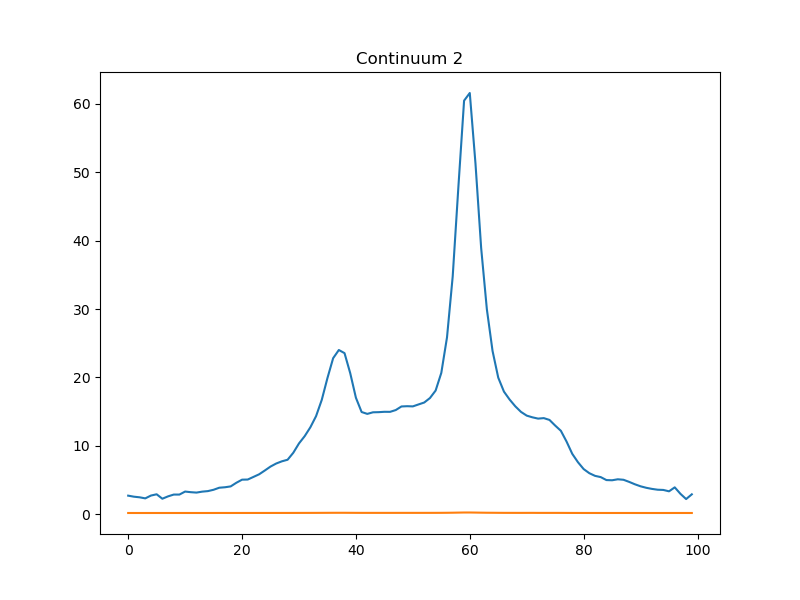

In [52]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [53]:
# Bounds:
bounds = bounds_HA
seeing_i = 3.174
sigma_i = seeing_i/ 2.35

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigma_i)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 13527.254156230141
differential_evolution step 2: f(x)= 10690.140204314856
differential_evolution step 3: f(x)= 10690.140204314856
differential_evolution step 4: f(x)= 6676.635865935941
differential_evolution step 5: f(x)= 6060.763586430798
differential_evolution step 6: f(x)= 6060.763586430798
differential_evolution step 7: f(x)= 5619.012669117607
differential_evolution step 8: f(x)= 4476.549506398012
differential_evolution step 9: f(x)= 3116.7963891240342
differential_evolution step 10: f(x)= 3116.7963891240342
differential_evolution step 11: f(x)= 3016.5802639193844
differential_evolution step 12: f(x)= 3016.5802639193844
differential_evolution step 13: f(x)= 3016.5802639193844
differential_evolution step 14: f(x)= 3016.5802639193844
differential_evolution step 15: f(x)= 2639.8629927828215
differential_evolution step 16: f(x)= 2639.8629927828215
differential_evolution step 17: f(x)= 2639.8629927828215
differential_evolution step 18: f(x)= 2172.85

Sérsic 1: I_e=1.2034, r_e=15.2336, n=1.7913, x_0=36.7601
Sérsic 2: I_e=1.5983, r_e=50.0000, n=1.0342, x_0=46.7149
Sérsic 3: I_e=2.0088, r_e=15.7451, n=2.4552, x_0=59.6797
Sérsic 4: I_e=0.7472, r_e=26.7212, n=1.4794, x_0=72.8053


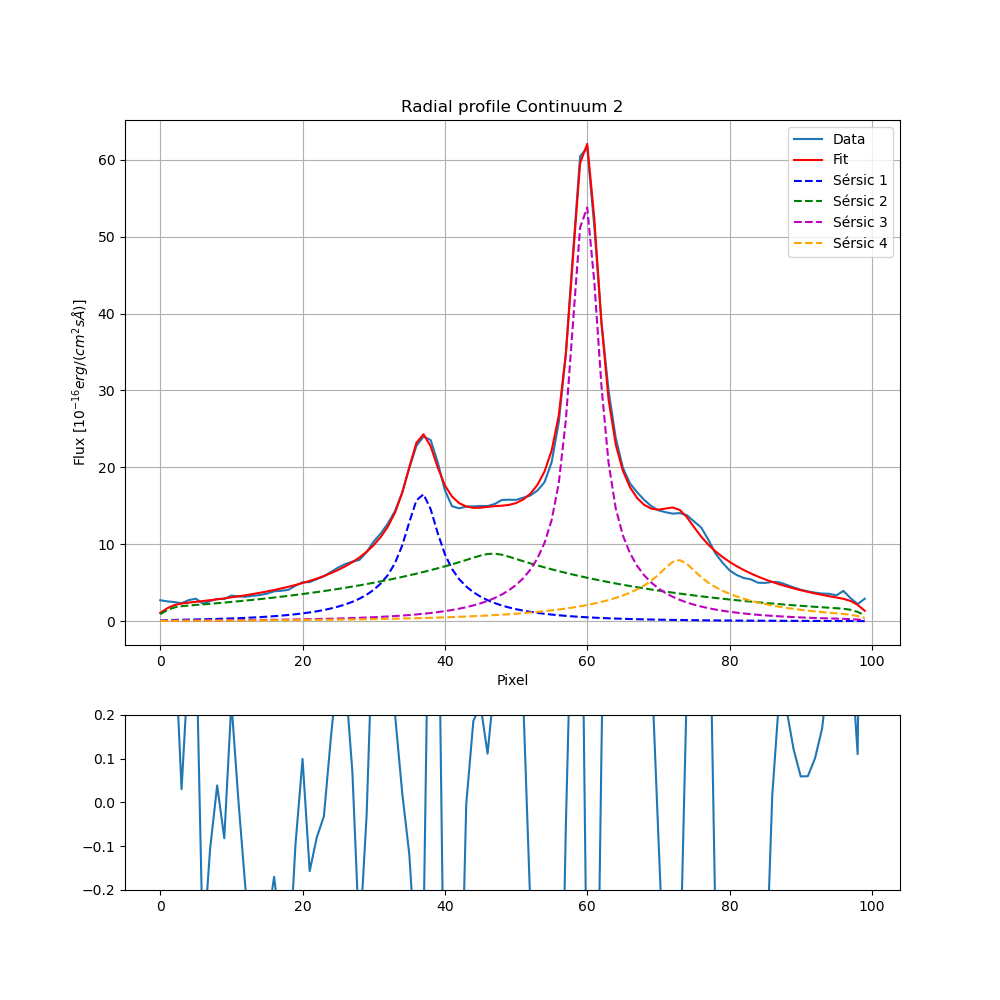

In [54]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigma_i,
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [55]:
bounds = [
    (0, 4),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 100),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 44),   # x_0: circa la posizione di Halpha

    (0, 4),
    (0, 100),
    (0.1, 10),
    (40, 50),

    (0, 4),
    (0, 100),
    (0.1, 10),
    (55, 65),

    (0, 4),
    (0, 100),
    (0.1, 10),
    (70, 80)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigma_i, *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigma_i, x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=2.1033, r_e=10.8129, n=1.3985, x_0=36.6872
Sérsic 2: I_e=0.8505, r_e=89.0294, n=1.3450, x_0=47.4776
Sérsic 3: I_e=1.6378, r_e=21.0708, n=2.5462, x_0=59.8110
Sérsic 4: I_e=0.2067, r_e=46.1916, n=2.3478, x_0=73.4326
[9.48083341e-01 5.73533346e+00 3.32183693e-01 1.94226161e-01
 1.38842421e+00 1.03113090e+02 6.62100796e-01 1.43373712e+00
 1.02641867e+01 1.05848720e+02 5.30907662e+00 8.08161438e-03
 4.85284572e-01 1.76905847e+02 1.52159132e+00 3.78810502e-01]
2.325425172377373


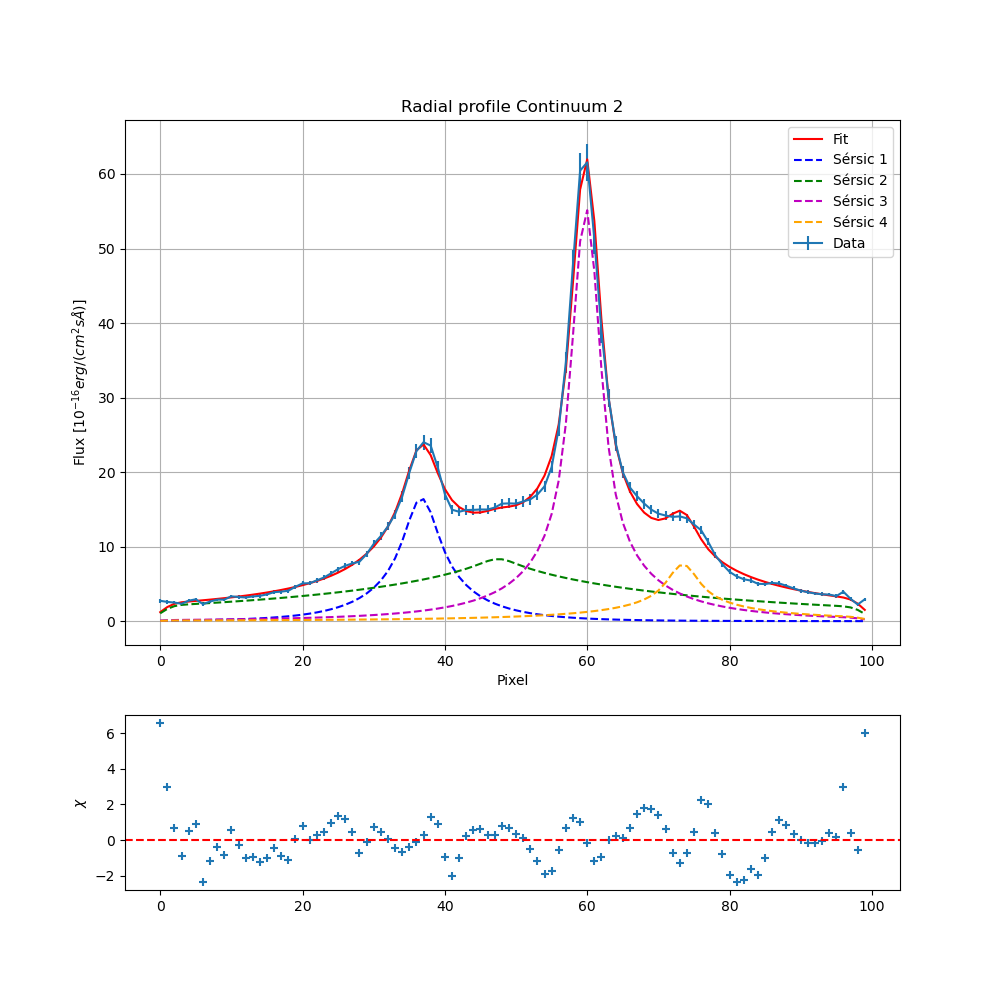

In [56]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

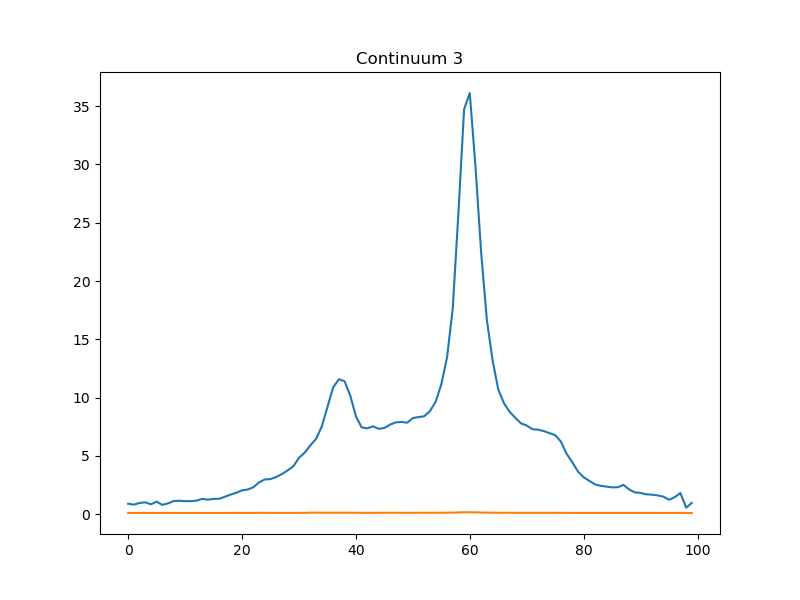

In [57]:
mask_continuum_3 = (wv > 6300)*(wv < 6600)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [58]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2428.5712161612214
differential_evolution step 2: f(x)= 2216.426399849693
differential_evolution step 3: f(x)= 2216.426399849693
differential_evolution step 4: f(x)= 2216.426399849693
differential_evolution step 5: f(x)= 2216.426399849693
differential_evolution step 6: f(x)= 2216.426399849693
differential_evolution step 7: f(x)= 2216.426399849693
differential_evolution step 8: f(x)= 2216.426399849693
differential_evolution step 9: f(x)= 2216.426399849693
differential_evolution step 10: f(x)= 2216.426399849693
differential_evolution step 11: f(x)= 2216.426399849693
differential_evolution step 12: f(x)= 2216.426399849693
differential_evolution step 13: f(x)= 2216.426399849693
differential_evolution step 14: f(x)= 2216.426399849693
differential_evolution step 15: f(x)= 2216.426399849693
differential_evolution step 16: f(x)= 2216.426399849693
differential_evolution step 17: f(x)= 2216.426399849693
differential_evolution step 18: f(x)= 1858.8740616141529

Sérsic 1: I_e=0.4302, r_e=38.6791, n=2.0261, x_0=37.0929
Sérsic 2: I_e=1.5693, r_e=3.3646, n=0.1421, x_0=47.5008
Sérsic 3: I_e=0.3692, r_e=49.1156, n=3.2312, x_0=59.7614
Sérsic 4: I_e=0.5005, r_e=19.2228, n=1.3217, x_0=73.0399


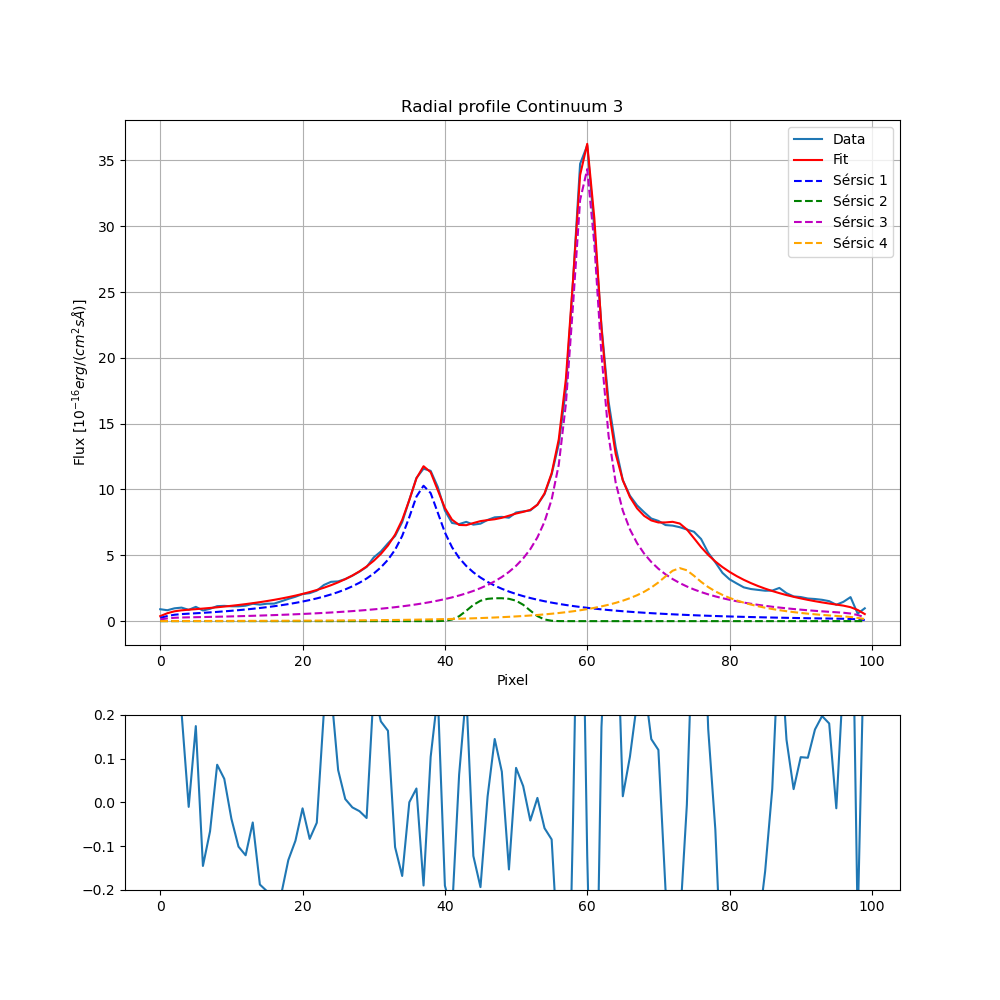

In [59]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [60]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2600\3904840282.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)


Optimize parameters with curve fit:
Sérsic 1: I_e=0.5584, r_e=26.1762, n=1.8525, x_0=37.0216
Sérsic 2: I_e=1.0179, r_e=3.8729, n=0.0649, x_0=47.0728
Sérsic 3: I_e=0.2462, r_e=81.9714, n=3.4287, x_0=59.7615
Sérsic 4: I_e=0.1048, r_e=37.4088, n=2.3756, x_0=73.6594
[2.80609293e-01 1.37022717e+01 3.45032171e-01 1.52237284e-01
 1.31937479e+01 1.05473922e+01 9.41664140e-01 5.96571964e-01
 3.49972205e-01 9.82016128e+01 1.15151508e+00 1.92261747e-02
 2.38534945e-01 9.14066093e+01 1.49493545e+00 2.70062155e-01]
1.7965370309120854


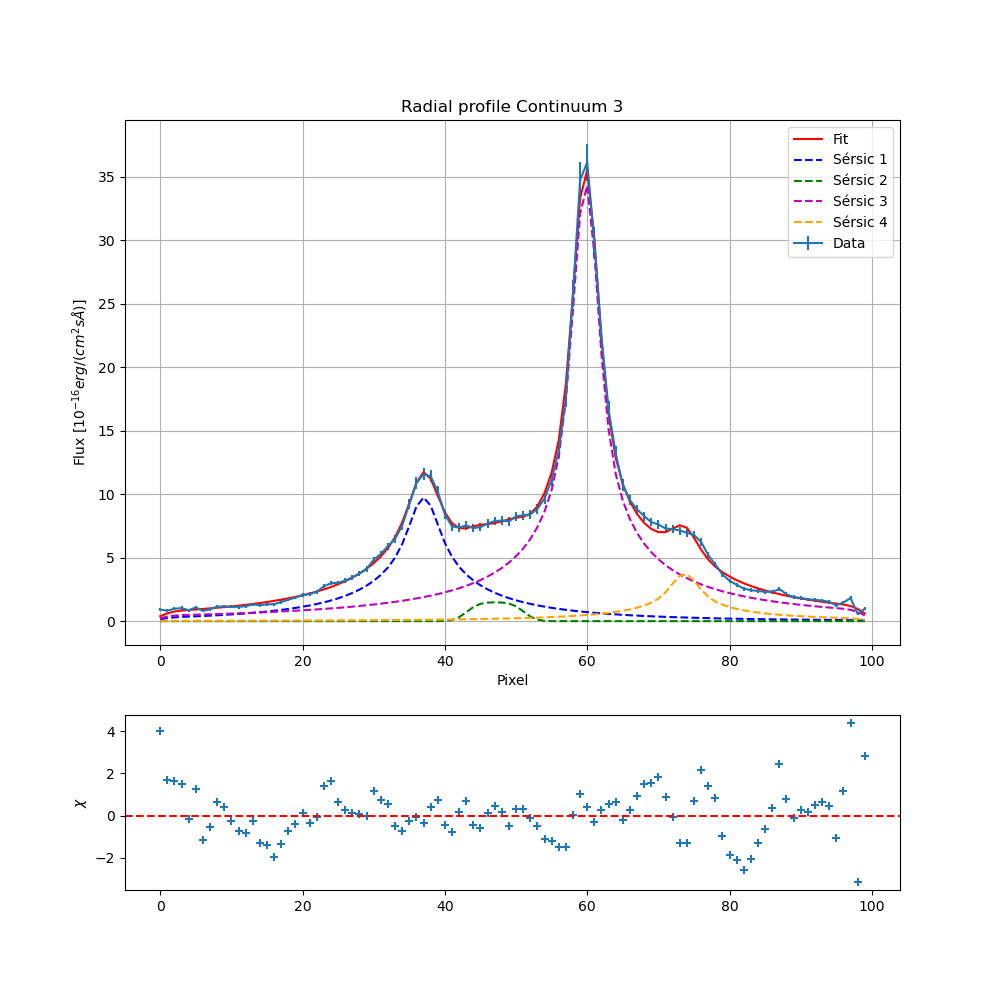

In [61]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

In [62]:
d1 = {'Name': ['Continuum 3'], 'Chi squared': chi2_continuum_3,
      'Dof': dof_continuum_3, 'Chi reduced': chi2_reduced_continuum_3}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_continuum_3.csv", index= False)

## Chi squared save

In [63]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

In [64]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))


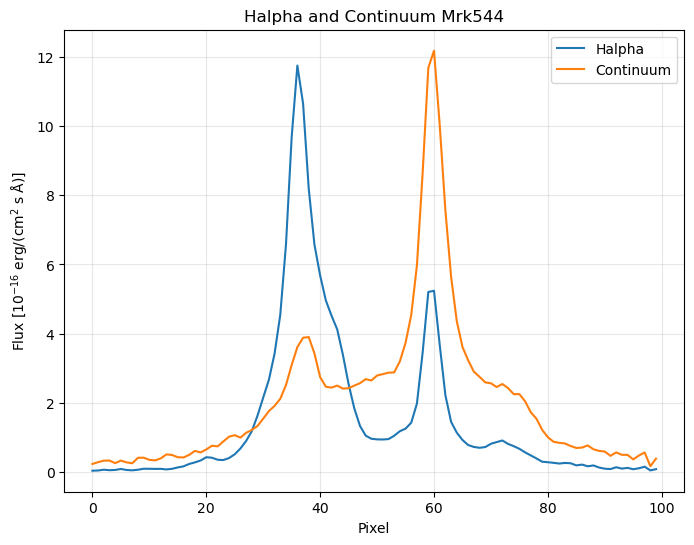

In [11]:
mask_continuum_3 = (wv > 6500)*(wv < 6600)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum Mrk544')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_Mrk544')